In [12]:
import pandas as pd
import numpy as np
from PIL import Image

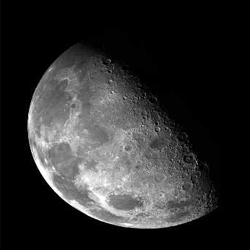

In [13]:
img = Image.open('images/moon.png').convert('L').resize((250,250))
img

In [14]:
imgMat = np.array(img, dtype=np.int32)
imgMat

array([[7, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0],
       ...,
       [7, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0]], shape=(250, 250), dtype=int32)

int8 range 0 to 255
int32 range -128 to 127 
using int32 during calculation to avoid negative pixels as pixel value can be bigger

### Blur using Box Filter

In [15]:
n = 5
def nineMul(i,j,mat):
    diff = [x for x in range(-n,n+1)]
    ct = 0
    prod = 0
    for dx in diff:
        if (i + dx) >= 0 and (i + dx) < len(mat):
            for dy in diff:
                if (j + dy) >= 0 and (j + dy) < len(mat[0]):
                    ct += 1
                    prod += mat[i + dx][j + dy]
    return prod // ct

In [16]:
#unsharp by subtracting the blurred image from the original image
blurMat = imgMat.copy()
for i in range(len(imgMat)):
    for j in range(len(imgMat[0])):
        blurred = nineMul(i, j, imgMat)
        blurMat[i][j] = min(max(0,imgMat[i][j] - blurred),255) #clipping the values to be between 0 and 255

In [17]:
fin = Image.fromarray(blurMat.astype(np.uint8))

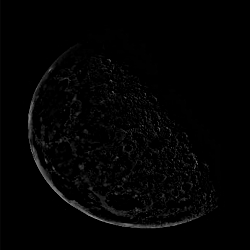

In [18]:
fin

In [19]:
fin.save('images/unsharp1.jpeg')

In [20]:
# highboost/unsharp masking using k value
blurMat = imgMat.copy()
k = 1
for i in range(len(imgMat)):
    for j in range(len(imgMat[0])):
        blurred = nineMul(i, j, imgMat)
        blurMat[i][j] = min(max(0,imgMat[i][j] + k*(imgMat[i][j] -  blurred)),255)

In [21]:
fin = Image.fromarray(blurMat.astype(np.uint8))

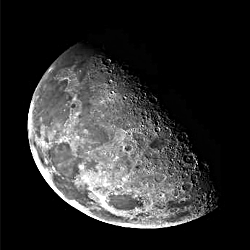

In [22]:
fin

In [23]:
fin.save('images/unsharp2.jpeg')